# 📈 Sales Prediction Using Machine Learning

### CodeAlpha Data Science Internship – Task 4

**Objective:**  
Predict product sales based on advertising expenditure using Machine Learning.

**Technologies Used:**  
- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn
- Joblib

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("advertising.csv")
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nDataset Information:")
df.info()

Shape: (200, 5)

Columns:
Index(['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [4]:
# Remove unnecessary index column
df = df.drop('Unnamed: 0', axis=1)

# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

# Display the cleaned dataset
df.head()

Missing values:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Duplicate rows: 0


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [5]:
# Input features
X = df[['TV', 'Radio', 'Newspaper']]

# Target variable
y = df['Sales']

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
      TV  Radio  Newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4

Target:
0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: Sales, dtype: float64


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (160, 3)
Testing data: (40, 3)


In [7]:
from sklearn.linear_model import LinearRegression

# Create the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [8]:
# Predict sales for test data
y_pred = model.predict(X_test)

print("Predicted Sales:")
print(y_pred[:10])

Predicted Sales:
[16.4080242  20.88988209 21.55384318 10.60850256 22.11237326 13.10559172
 21.05719192  7.46101034 13.60634581 15.15506967]


In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("-----------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

Model Evaluation
-----------------
MAE : 1.4607567168117606
MSE : 3.1740973539761055
RMSE: 1.7815996615334506
R²  : 0.899438024100912


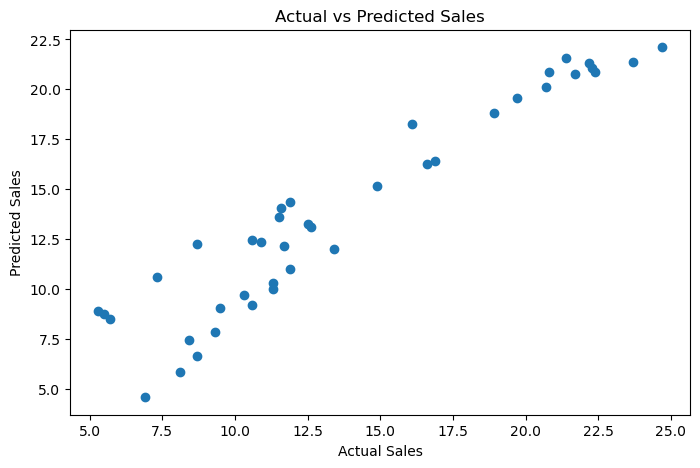

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

In [11]:
# Check correlation between advertising channels and sales

correlation = df[['TV', 'Radio', 'Newspaper', 'Sales']].corr()

print(correlation['Sales'].sort_values(ascending=False))

Sales        1.000000
TV           0.782224
Radio        0.576223
Newspaper    0.228299
Name: Sales, dtype: float64


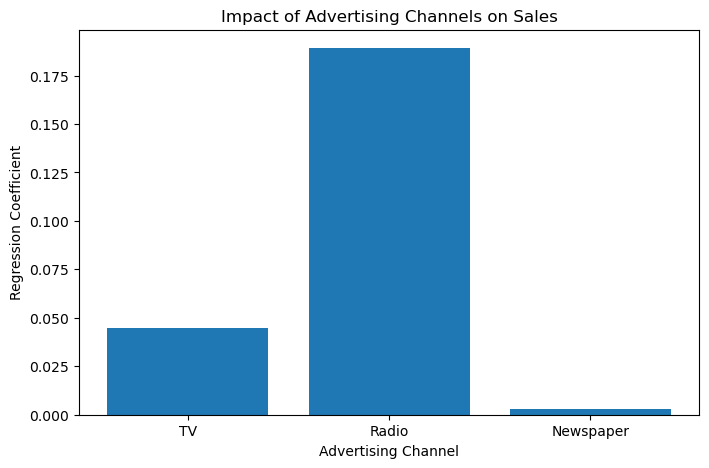

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(['TV', 'Radio', 'Newspaper'], model.coef_)
plt.xlabel("Advertising Channel")
plt.ylabel("Regression Coefficient")
plt.title("Impact of Advertising Channels on Sales")
plt.show()

In [13]:
import joblib

joblib.dump(model, "sales_prediction_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [14]:
results = pd.DataFrame({
    'Actual Sales': y_test.values,
    'Predicted Sales': y_pred
})

results.to_csv("sales_prediction_results.csv", index=False)

print("Prediction results saved successfully!")

Prediction results saved successfully!


## 11. Conclusion

A Linear Regression model was developed to predict sales based on advertising expenditure across TV, Radio, and Newspaper channels.

The model achieved an R² score of approximately 89.9% on the test data, indicating that the model explains a substantial portion of the variation in sales for this test set.

The analysis also examined the relationship between advertising channels and sales using correlations and regression coefficients.

This project demonstrates how machine learning can be used to predict sales and analyze the relationship between advertising expenditure and sales performance.